In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


Observation of RAW data

In [2]:
df = pd.read_csv("../data/screentime_and_stress.csv")
df.shape

(15000, 13)

In [3]:
df.sample(5)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
7909,7910,54,Male,Doctor,9.11,52,4.82,4.47,10.00,1,12,299,9.70
6732,6733,29,Female,Teacher,8.17,54,5.11,4.96,9.80,0,40,180,10.00
12413,12414,57,Male,Software Engineer,8.18,62,6.42,4.16,10.00,0,16,223,10.00
8598,8599,42,Other,Researcher,8.46,16,8.48,6.89,9.09,3,2,115,8.95
2163,2164,58,Female,Manager,3.75,19,8.84,7.37,6.52,4,44,78,6.94


In [4]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  str    
 3   occupation                        15000 non-null  str    
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  mental_fatigue_

In [6]:
df.duplicated().sum()

np.int64(0)

Observing relationships between variables

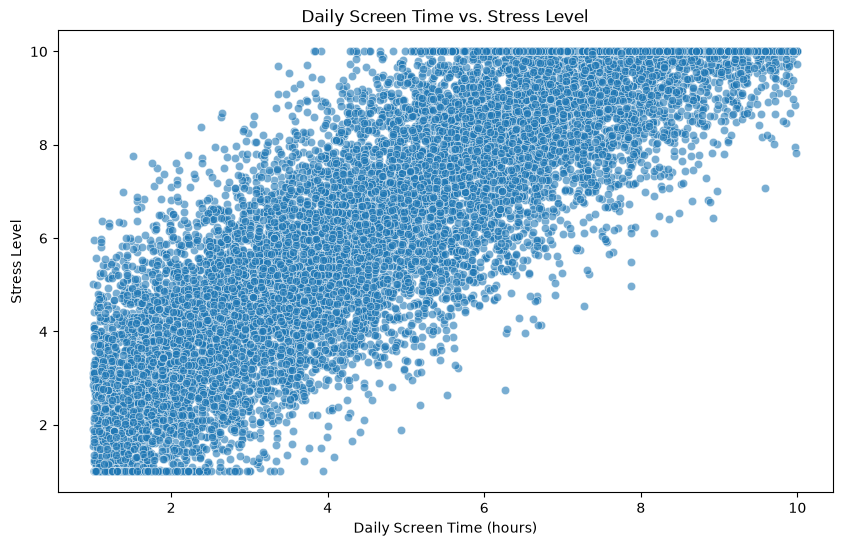

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='stress_level', data=df, alpha=0.6)
plt.title('Daily Screen Time vs. Stress Level')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Stress Level')
plt.show()

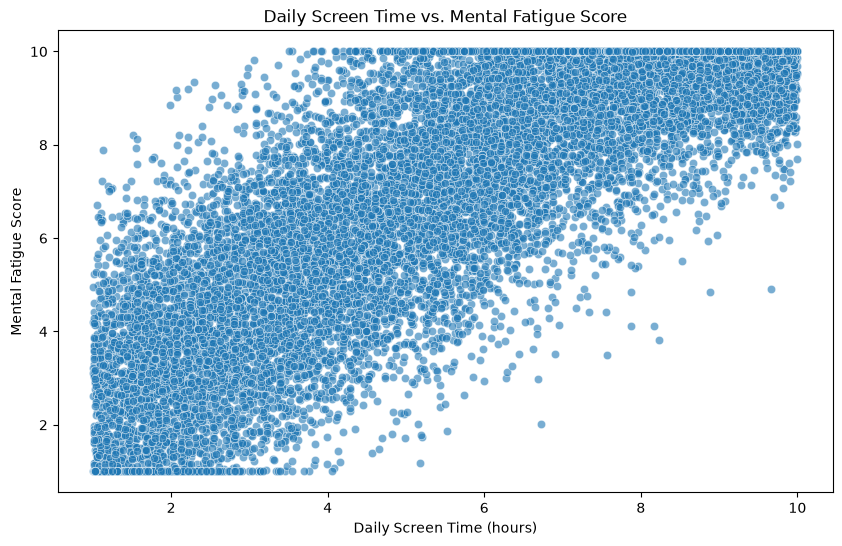

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='mental_fatigue_score', data=df, alpha=0.6)
plt.title('Daily Screen Time vs. Mental Fatigue Score')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Mental Fatigue Score')
plt.show()

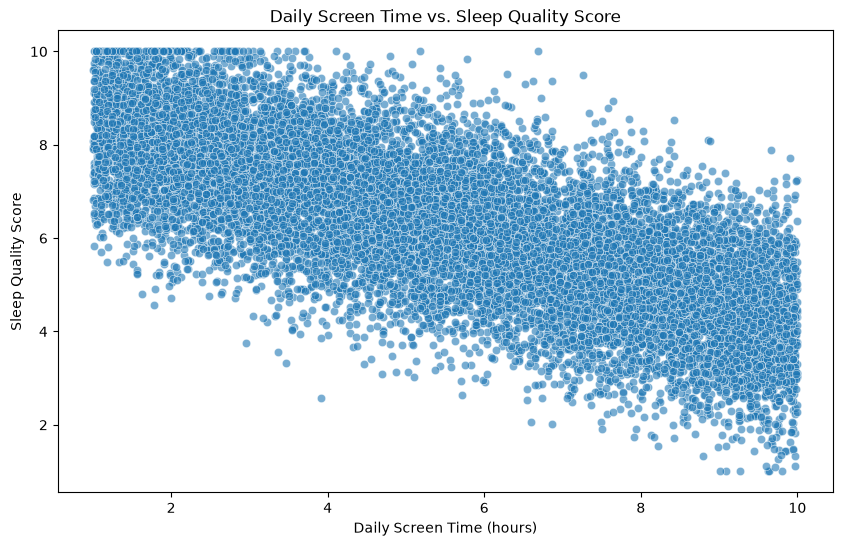

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='sleep_quality_score', data=df, alpha=0.6)
plt.title('Daily Screen Time vs. Sleep Quality Score')
plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Sleep Quality Score')
plt.show()

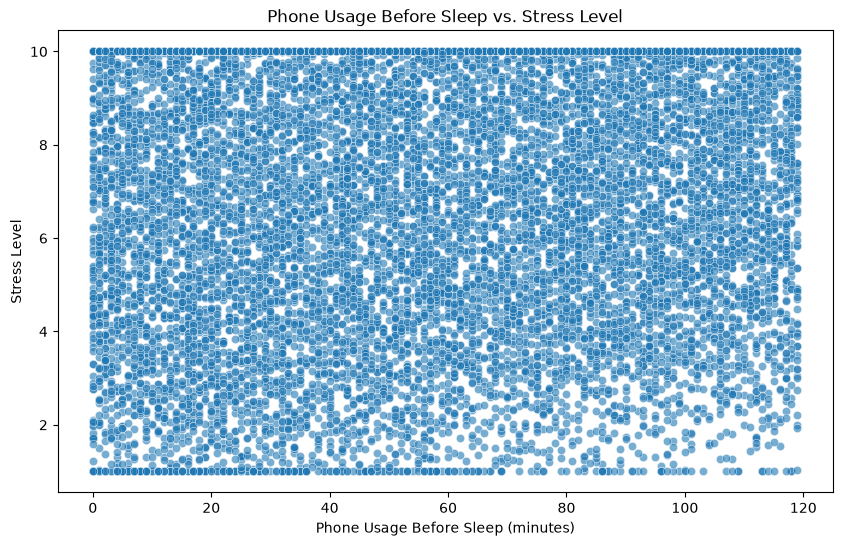

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='phone_usage_before_sleep_minutes', y='stress_level', data=df, alpha=0.6)
plt.title('Phone Usage Before Sleep vs. Stress Level')
plt.xlabel('Phone Usage Before Sleep (minutes)')
plt.ylabel('Stress Level')
plt.show()

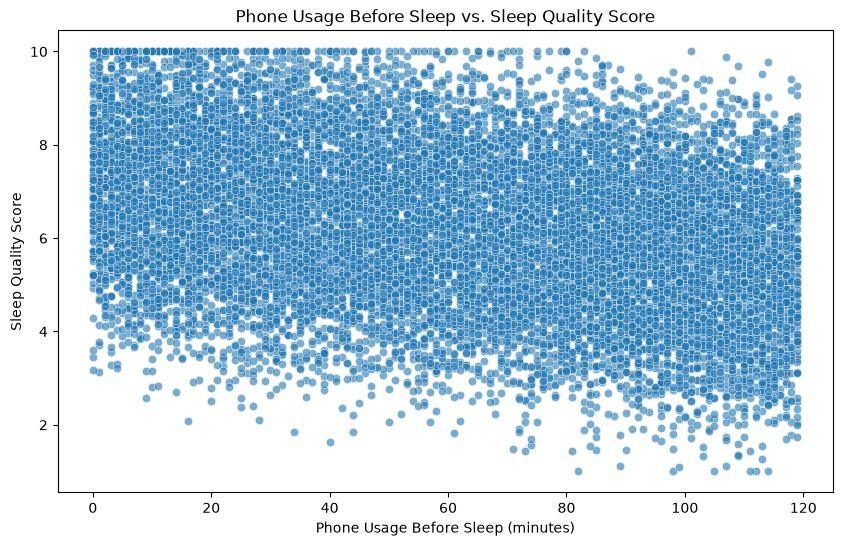

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='phone_usage_before_sleep_minutes', y='sleep_quality_score', data=df, alpha=0.6)
plt.title('Phone Usage Before Sleep vs. Sleep Quality Score')
plt.xlabel('Phone Usage Before Sleep (minutes)')
plt.ylabel('Sleep Quality Score')
plt.show()

In [12]:
# Assuming productivity is inversely related to mental fatigue
# We can scale the mental_fatigue_score to create a 'derived_productivity' score.
# A simple inverse could be max_score - mental_fatigue_score + 1 (if scores start from 1)
# Or, given mental_fatigue_score is 1-10, productivity could be 11 - mental_fatigue_score.
# Let's create a derived productivity score (1-10 scale where 10 is most productive)
df['derived_productivity'] = 11 - df['mental_fatigue_score']

display(df.head())

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,derived_productivity
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,7.43
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91,9.09
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05,4.95
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92,1.08
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99,5.01


In [13]:
# Display the correlations involving the new 'derived_productivity' column
display(df.corr(numeric_only=True)['derived_productivity'].sort_values(ascending=False))

derived_productivity                1.000000
sleep_quality_score                 0.808019
sleep_duration_hours                0.011073
notifications_received_per_day      0.005077
caffeine_intake_cups                0.002722
user_id                            -0.005458
age                                -0.009724
physical_activity_minutes          -0.010254
phone_usage_before_sleep_minutes   -0.150180
daily_screen_time_hours            -0.828368
stress_level                       -0.948768
mental_fatigue_score               -1.000000
Name: derived_productivity, dtype: float64

In [14]:
df.corr(numeric_only=True)

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,derived_productivity
user_id,1.000000,-0.009833,0.010960,-0.003865,-0.014394,-0.004342,0.009981,0.003379,0.000799,-0.003432,0.005458,-0.005458
age,-0.009833,1.000000,0.009094,-0.007754,-0.005847,-0.000466,0.002849,-0.019182,-0.005827,-0.001594,0.009724,-0.009724
daily_screen_time_hours,0.010960,0.009094,1.000000,0.004228,-0.001838,-0.746531,0.879001,0.006128,0.002899,-0.003357,0.828368,-0.828368
phone_usage_before_sleep_minutes,-0.003865,-0.007754,0.004228,1.000000,-0.012930,-0.335283,0.155330,0.004639,-0.012705,-0.000691,0.150180,-0.150180
sleep_duration_hours,-0.014394,-0.005847,-0.001838,-0.012930,1.000000,0.009990,-0.004893,-0.013682,-0.001118,0.005343,-0.011073,0.011073
sleep_quality_score,-0.004342,-0.000466,-0.746531,-0.335283,0.009990,1.000000,-0.857463,-0.009033,-0.005857,0.003354,-0.808019,0.808019
stress_level,0.009981,0.002849,0.879001,0.155330,-0.004893,-0.857463,1.000000,0.003458,0.009360,-0.002808,0.948768,-0.948768
caffeine_intake_cups,0.003379,-0.019182,0.006128,0.004639,-0.013682,-0.009033,0.003458,1.000000,0.010249,0.006762,-0.002722,0.002722
physical_activity_minutes,0.000799,-0.005827,0.002899,-0.012705,-0.001118,-0.005857,0.009360,0.010249,1.000000,0.006069,0.010254,-0.010254
notifications_received_per_day,-0.003432,-0.001594,-0.003357,-0.000691,0.005343,0.003354,-0.002808,0.006762,0.006069,1.000000,-0.005077,0.005077
